# **Energy Demand Forecasting using Time-Series Deep Learning Models**

### Dataset Link: https://www.kaggle.com/datasets/pinuto/us-oil-and-gas-production-and-disposition-20152025

# Data Loading

In [1]:
# Step 1: Load and inspect the dataset
# Import required libraries
import pandas as pd
import numpy as np

# Load dataset
file_path = "OGORBcsv_cleaned.csv"
df = pd.read_csv(file_path)

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumns in dataset:\n", df.columns.tolist())

# Display first few rows
print("\nPreview of dataset:")
print(df.head())

# Step 2: Check data types and missing values
print("\nData types:\n", df.dtypes)
print("\nMissing values (in %):\n", (df.isna().mean() * 100).round(2))

# Step 3: Convert date and volume columns
# Convert 'Production Date' to datetime format
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')

# Convert 'Volume' to numeric (remove commas if needed)
df['Volume'] = df['Volume'].replace(',', '', regex=True)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Step 4: Quick summary after cleaning
print("\nDate range:", df['Production Date'].min(), "to", df['Production Date'].max())
print("Unique states:", df['State'].nunique())
print("Unique commodities:", df['Commodity'].nunique())
print("Unique land classes:", df['Land Class'].nunique())
print("Unique disposition types:", df['Disposition Description'].nunique())

Dataset shape: (470830, 11)

Columns in dataset:
 ['Production Date', 'Land Class', 'Land Category', 'State', 'County', 'FIPS Code', 'Offshore Region', 'Commodity', 'Disposition Code', 'Disposition Description', 'Volume']

Preview of dataset:
  Production Date Land Class Land Category     State    County FIPS Code  \
0      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   
1      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   
2      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   
3      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   
4      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   

    Offshore Region  Commodity  Disposition Code  \
0   Offshore Alaska  Gas (Mcf)                 1   
1     Offshore Gulf  Gas (Mcf)                 1   
2  Offshore Pacific  Gas (Mcf)                 1   
3     Offshore Gulf  Gas (Mcf)                 4   
4  Offshore Pacific  Gas (Mcf)          

# Data Preparation

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Convert 'Production Date' to datetime and 'Volume' to numeric for consistency
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Create a new 'Month' column by converting dates to monthly periods
df['Month'] = df['Production Date'].values.astype('datetime64[M]')

# Aggregate monthly total production by summing all records for the same month
monthly_df = df.groupby('Month')['Volume'].sum().reset_index()

# Print dataset shape and preview for verification
print("Aggregated monthly data shape:", monthly_df.shape)
print("Preview of monthly totals:\n", monthly_df.head())

# Create a full monthly range from the minimum to maximum date to fill any missing months
full_range = pd.date_range(start=monthly_df['Month'].min(), end=monthly_df['Month'].max(), freq='MS')
monthly_df = monthly_df.set_index('Month').reindex(full_range).fillna(0.0).rename_axis('Month').reset_index()
monthly_df.columns = ['Month', 'Volume']

# Apply MinMax scaling to normalize the data for LSTM input
scaler = MinMaxScaler(feature_range=(0, 1))
monthly_df['Scaled_Volume'] = scaler.fit_transform(monthly_df[['Volume']])

# Show scaled values for inspection
print("After scaling:\n", monthly_df.head())

# Define a function to create lookback sequences for LSTM
def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Generate sequences using a 24-month lookback window
lookback = 24
values = monthly_df['Scaled_Volume'].values
X, y = create_sequences(values, lookback)

# Display shapes of input and output arrays
print("LSTM input shape:", X.shape)
print("LSTM output shape:", y.shape)

# Split data into training and testing sets (80% train, 20% test)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Display number of samples for each set
print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

# Reshape data for LSTM input format [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Confirm final input shape for the model
print("Final LSTM input shape:", X_train.shape)

Aggregated monthly data shape: (125, 2)
Preview of monthly totals:
        Month     Volume
0 2015-01-01  499300687
1 2015-02-01  451972556
2 2015-03-01  493122773
3 2015-04-01  497089327
4 2015-05-01  505458541
After scaling:
        Month     Volume  Scaled_Volume
0 2015-01-01  499300687       0.454254
1 2015-02-01  451972556       0.176125
2 2015-03-01  493122773       0.417949
3 2015-04-01  497089327       0.441259
4 2015-05-01  505458541       0.490442
LSTM input shape: (101, 24)
LSTM output shape: (101,)
Train samples: 80
Test samples: 21
Final LSTM input shape: (80, 24, 1)


# Exploratory Data Analysis (EDA)

Dataset shape: (470830, 12)
Missing values (in %):
 Production Date            0.0
Land Class                 0.0
Land Category              0.0
State                      0.0
County                     0.0
FIPS Code                  0.0
Offshore Region            0.0
Commodity                  0.0
Disposition Code           0.0
Disposition Description    0.0
Volume                     0.0
Month                      0.0
dtype: float64
Date range: 2015-01-01 00:00:00 to 2025-05-01 00:00:00


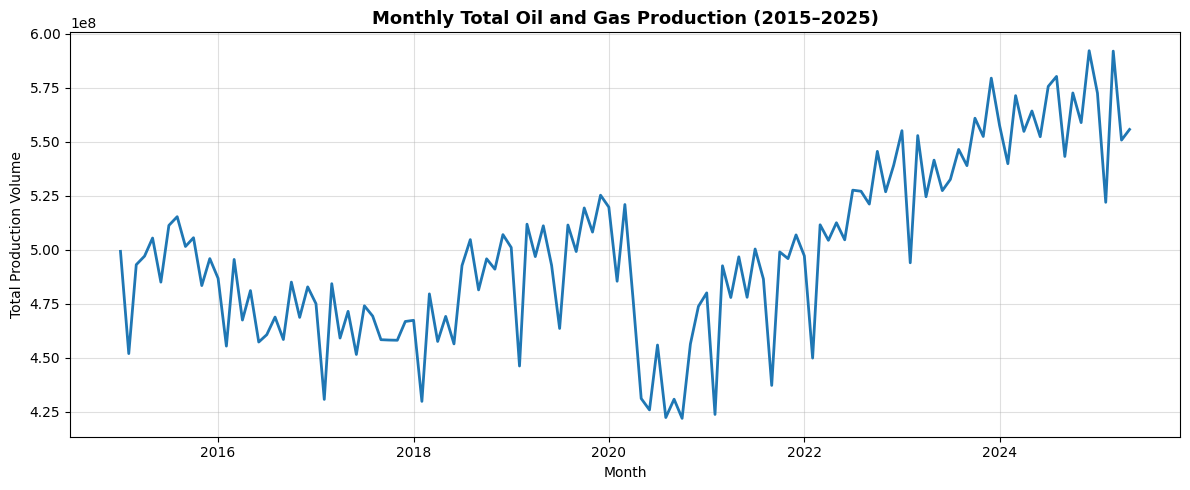

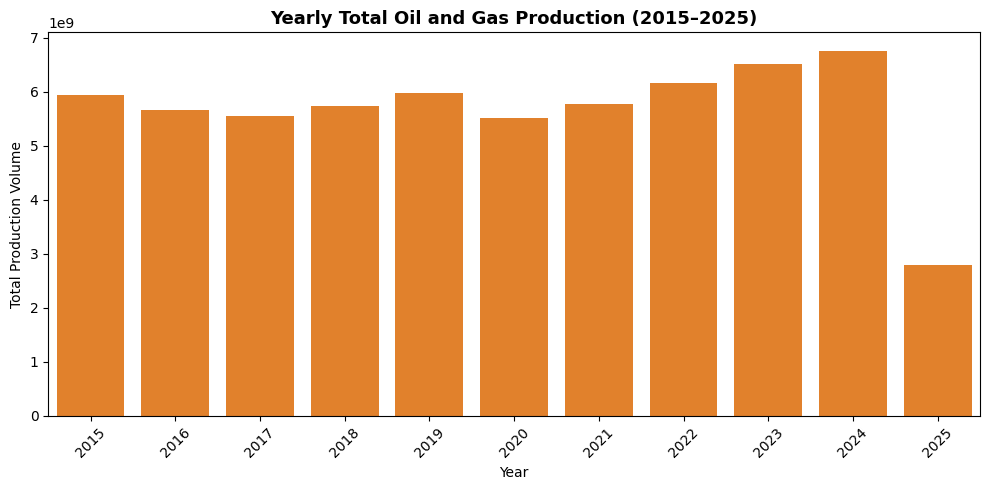

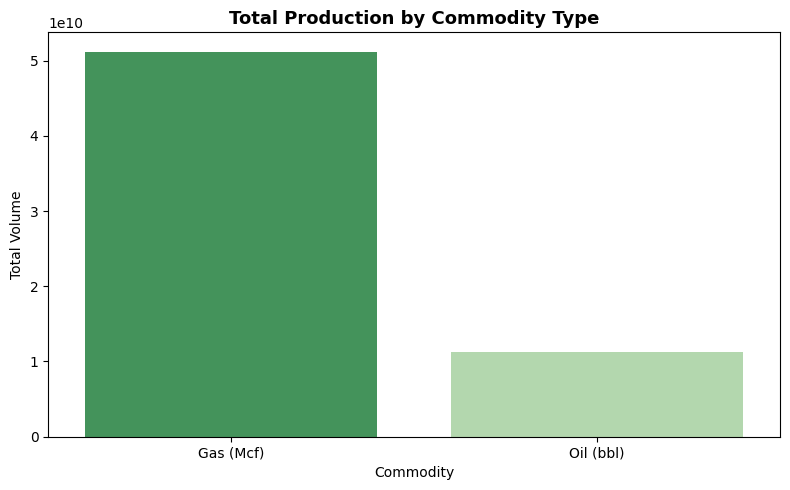

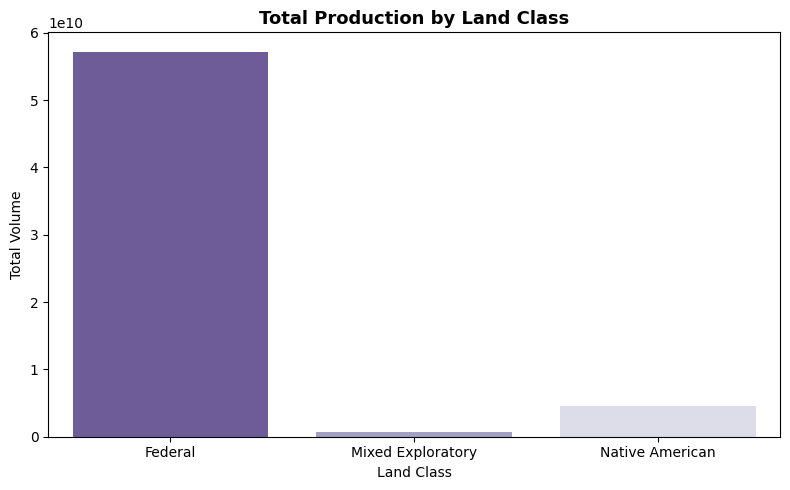

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Convert necessary columns
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')
df['Volume'] = df['Volume'].replace(',', '', regex=True)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Basic information
print("Dataset shape:", df.shape)
print("Missing values (in %):\n", (df.isna().mean() * 100).round(2))
print("Date range:", df['Production Date'].min(), "to", df['Production Date'].max())

# Create monthly and yearly aggregations
df['Month'] = df['Production Date'].values.astype('datetime64[M]')
df['Year'] = df['Production Date'].dt.year
monthly_df = df.groupby('Month')['Volume'].sum().reset_index()
yearly_df = df.groupby('Year')['Volume'].sum().reset_index()

# 1. Monthly total production trend (Blue theme)
plt.figure(figsize=(12, 5))
plt.plot(monthly_df['Month'], monthly_df['Volume'], color='#1f77b4', linewidth=2)
plt.title("Monthly Total Oil and Gas Production (2015–2025)", fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Production Volume")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# 2. Yearly total production trend (Orange theme)
plt.figure(figsize=(10, 5))
sns.barplot(x='Year', y='Volume', data=yearly_df, color='#ff7f0e')
plt.title("Yearly Total Oil and Gas Production (2015–2025)", fontsize=13, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Total Production Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Total production by commodity type (Green theme)
plt.figure(figsize=(8, 5))
commodity_df = df.groupby('Commodity')['Volume'].sum().reset_index()
sns.barplot(x='Commodity', y='Volume', data=commodity_df, palette='Greens_r')
plt.title("Total Production by Commodity Type", fontsize=13, fontweight='bold')
plt.xlabel("Commodity")
plt.ylabel("Total Volume")
plt.tight_layout()
plt.show()

# 4. Total production by land class (Purple theme)
plt.figure(figsize=(8, 5))
land_df = df.groupby('Land Class')['Volume'].sum().reset_index()
sns.barplot(x='Land Class', y='Volume', data=land_df, palette='Purples_r')
plt.title("Total Production by Land Class", fontsize=13, fontweight='bold')
plt.xlabel("Land Class")
plt.ylabel("Total Volume")
plt.tight_layout()
plt.show()

# Model Training

## Long Short-Term Memory (LSTM)

X_train: (80, 24, 1) X_test: (21, 24, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 572ms/step - loss: 0.0854 - val_loss: 0.2684 - learning_rate: 0.0010
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0605 - val_loss: 0.1813 - learning_rate: 0.0010
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.0361 - val_loss: 0.1076 - learning_rate: 0.0010
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0251 - val_loss: 0.0504 - learning_rate: 0.0010
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0211 - val_loss: 0.0199 - learning_rate: 0.0010
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0242 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0261 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0252 - val_loss: 0.0286 - learning_rate: 0.0010
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0233 - val_loss: 0.0432 - learning_rate: 0.0010
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━

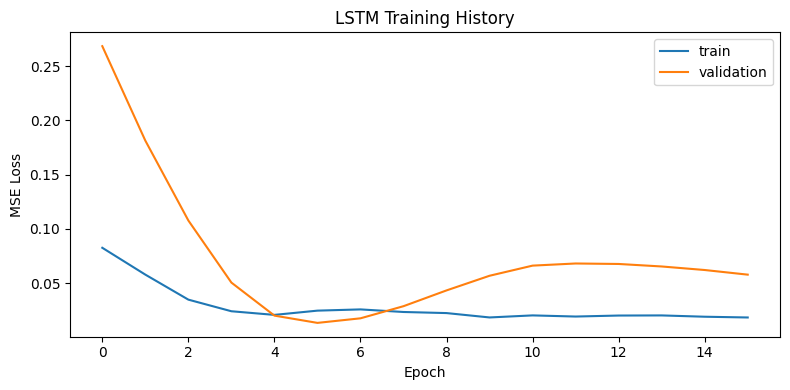

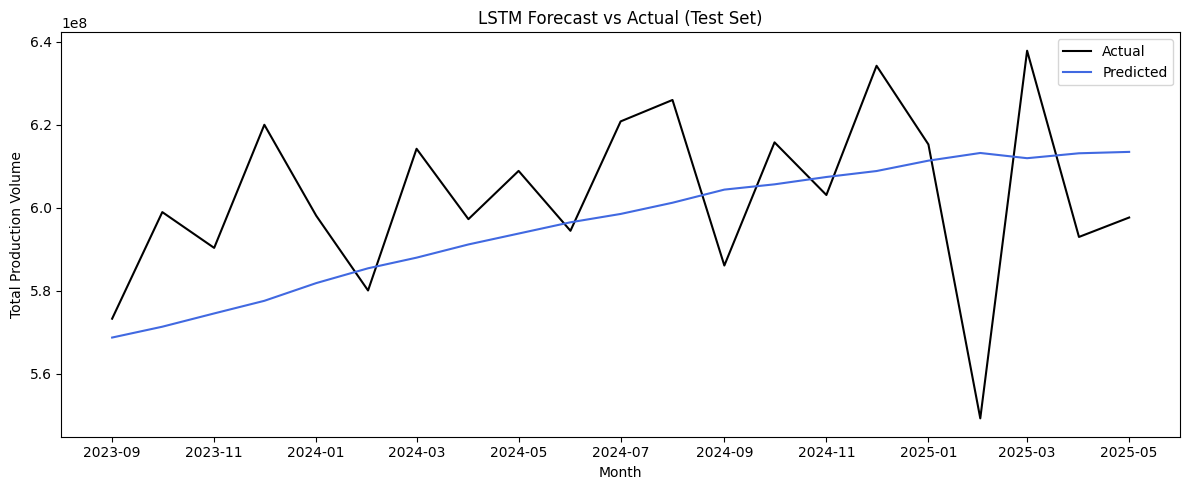


LSTM 3-Month Production Forecast
Forecast Month  Predicted Production Volume
      Jun 2025                  613488448.0
      Jul 2025                  614104640.0
      Aug 2025                  615077184.0


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Convert columns to proper types
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')
df['Volume'] = df['Volume'].replace(',', '', regex=True)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Drop missing or invalid rows
df = df.dropna(subset=['Production Date', 'Volume'])
df = df[df['Volume'] > 0]

# Aggregate monthly total production
df['Month'] = df['Production Date'].values.astype('datetime64[M]')
monthly_df = df.groupby('Month')['Volume'].sum().reset_index()

# Fill missing months
full_range = pd.date_range(start=monthly_df['Month'].min(), end=monthly_df['Month'].max(), freq='MS')
monthly_df = monthly_df.set_index('Month').reindex(full_range).fillna(0.0).rename_axis('Month').reset_index()
monthly_df.columns = ['Month', 'Volume']

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
monthly_df['Scaled_Volume'] = scaler.fit_transform(monthly_df[['Volume']])

# Create sequences for LSTM
def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lookback = 24
values = monthly_df['Scaled_Volume'].values
X, y = create_sequences(values, lookback)

# Split train-test sets (80-20 split)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train:", X_train.shape, "X_test:", X_test.shape)

# Build LSTM model
def build_lstm(input_timesteps, input_features):
    model = keras.Sequential([
        layers.Input(shape=(input_timesteps, input_features)),
        layers.LSTM(64, activation='tanh'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    return model

model = build_lstm(X_train.shape[1], X_train.shape[2])
model.summary()

# Callbacks for early stopping and learning rate reduction
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Predict
y_pred_scaled = model.predict(X_test).ravel()

# Inverse scale
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_inv = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Evaluate performance
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)  # compute RMSE manually
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / np.clip(np.abs(y_test_inv), 1e-8, None))) * 100
accuracy = 100 - mape

print(f"Test RMSE: {rmse:,.2f}")
print(f"Test MAE: {mae:,.2f}")
print(f"Test MAPE: {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Plot actual vs predicted
test_months = monthly_df['Month'].iloc[-len(y_test):].reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(test_months, y_test_inv, label='Actual', color='black')
plt.plot(test_months, y_pred_inv, label='Predicted', color='royalblue')
plt.title('LSTM Forecast vs Actual (Test Set)')
plt.xlabel('Month')
plt.ylabel('Total Production Volume')
plt.legend()
plt.tight_layout()
plt.show()

def recursive_forecast(model, scaler, last_sequence, steps=3, last_date=None):
    # Make a copy of the last input sequence
    seq = last_sequence.copy()
    preds = []

    # Predict step-by-step, feeding each prediction back into the sequence
    for _ in range(steps):
        pred_scaled = model.predict(seq[np.newaxis, :, :], verbose=0).ravel()[0]
        preds.append(pred_scaled)
        seq = np.vstack([seq[1:], [[pred_scaled]]])  # slide window forward

    # Convert scaled predictions back to original units
    preds_inv = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).ravel()

    # Generate future month labels
    if last_date is not None:
        future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=steps, freq='MS')
        forecast_df = pd.DataFrame({
            'Forecast Month': future_dates.strftime('%b %Y'),
            'Predicted Production Volume': np.round(preds_inv, 2)
        })
    else:
        forecast_df = pd.DataFrame({
            'Step': np.arange(1, steps + 1),
            'Predicted Production Volume': np.round(preds_inv, 2)
        })

    return forecast_df
# Get the last date from your dataset
last_date = monthly_df['Month'].max()

# Generate a 3-month forecast
forecast_df = recursive_forecast(model, scaler, last_sequence=X_test[-1], steps=3, last_date=last_date)

# Print the results
print("\nLSTM 3-Month Production Forecast")
print(forecast_df.to_string(index=False))

## Seasonal Autoregressive Integrated Moving Average (SARIMA)

Training data range: 2015-01-01 00:00:00 to 2023-04-01 00:00:00
Testing data range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00

SARIMA Model Performance Summary
RMSE: 17,749,643.50
MAE: 14,333,820.39
MAPE: 2.42%
Accuracy: 97.58%


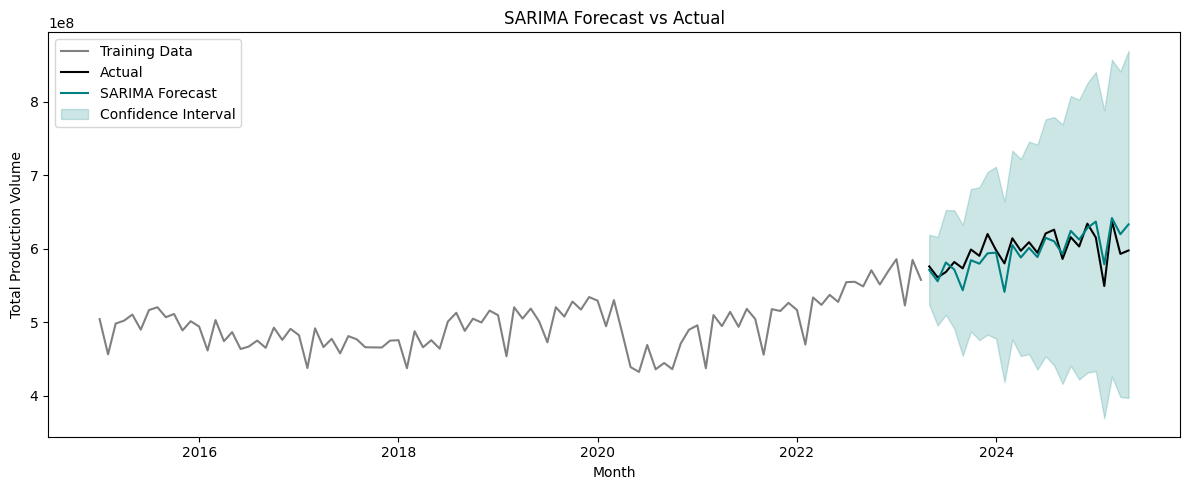


SARIMA 3-Month Future Forecast
Forecast Month  Predicted Production Volume
      Jun 2025                 571315326.94
      Jul 2025                 555789423.42
      Aug 2025                 581354114.02


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Convert data types
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')
df['Volume'] = df['Volume'].replace(',', '', regex=True)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Remove missing or invalid values
df = df.dropna(subset=['Production Date', 'Volume'])
df = df[df['Volume'] > 0]

# Aggregate monthly totals
df['Month'] = df['Production Date'].values.astype('datetime64[M]')
monthly_df = df.groupby('Month')['Volume'].sum().reset_index()

# Fill missing months (if any)
full_range = pd.date_range(start=monthly_df['Month'].min(), end=monthly_df['Month'].max(), freq='MS')
monthly_df = monthly_df.set_index('Month').reindex(full_range).fillna(0.0).rename_axis('Month').reset_index()
monthly_df.columns = ['Month', 'Volume']

# Split train-test sets (same ratio as LSTM)
split_index = int(len(monthly_df) * 0.8)
train = monthly_df.iloc[:split_index]
test = monthly_df.iloc[split_index:]

print("Training data range:", train['Month'].min(), "to", train['Month'].max())
print("Testing data range:", test['Month'].min(), "to", test['Month'].max())

# Build and fit SARIMA model
# (1,1,1)(1,1,1,12) is a good starting configuration for monthly seasonality
model = SARIMAX(train['Volume'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_result = model.fit(disp=False)

# Forecast on test period
forecast = sarima_result.get_forecast(steps=len(test))
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(test['Volume'], pred_mean))
mae = mean_absolute_error(test['Volume'], pred_mean)
mape = np.mean(np.abs((test['Volume'] - pred_mean) / np.clip(np.abs(test['Volume']), 1e-8, None))) * 100
accuracy = 100 - mape

# Print results
print("\nSARIMA Model Performance Summary")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(train['Month'], train['Volume'], label='Training Data', color='gray')
plt.plot(test['Month'], test['Volume'], label='Actual', color='black')
plt.plot(test['Month'], pred_mean, label='SARIMA Forecast', color='teal')
plt.fill_between(test['Month'], conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='teal', alpha=0.2, label='Confidence Interval')
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Month')
plt.ylabel('Total Production Volume')
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Forecast the next 3 months beyond the dataset
future_steps = 3
future_forecast = sarima_result.get_forecast(steps=future_steps)
future_pred = future_forecast.predicted_mean
future_dates = pd.date_range(start=monthly_df['Month'].max() + pd.offsets.MonthBegin(1), periods=future_steps, freq='MS')

# Display future forecast
future_df = pd.DataFrame({
    'Forecast Month': future_dates.strftime('%b %Y'),
    'Predicted Production Volume': np.round(future_pred.values, 2)
})
print("\nSARIMA 3-Month Future Forecast")
print(future_df.to_string(index=False))

# Model Comparison


Model Performance Comparison (Length-Aligned)
Metric                    LSTM         SARIMA
---------------------------------------------
RMSE             23,621,175.34  18,963,208.18
MAE              18,868,478.38  15,483,119.01
MAPE (%)                  3.15           2.60
Accuracy (%)             96.85          97.40


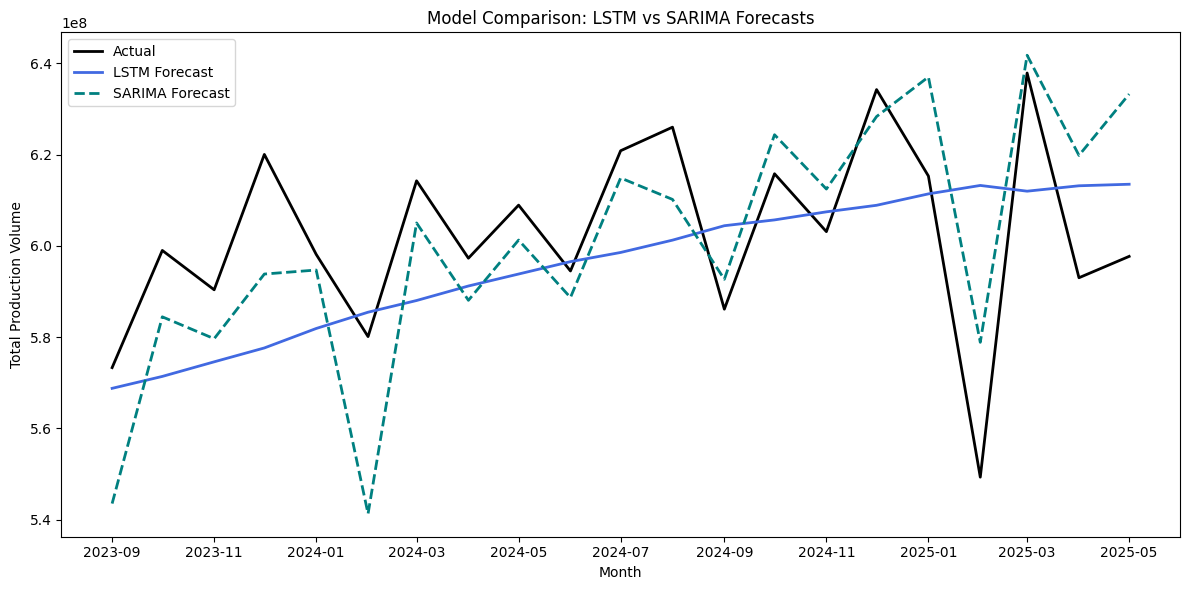



Summary Table:
      Metric        LSTM      SARIMA
        RMSE 23621175.34 18963208.18
         MAE 18868478.38 15483119.01
    MAPE (%)        3.15        2.60
Accuracy (%)       96.85       97.40


In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Convert SARIMA predictions to array
sarima_preds = np.array(pred_mean.values)

# Align lengths automatically
min_length = min(len(y_test_inv), len(y_pred_inv), len(sarima_preds), len(test['Month']))

# Trim everything to the same length
y_test_inv = y_test_inv[-min_length:]
y_pred_inv = y_pred_inv[-min_length:]
sarima_preds = sarima_preds[-min_length:]
dates = test['Month'].reset_index(drop=True)[-min_length:]

# Create aligned comparison dataframe
comparison_df = pd.DataFrame({
    'date': dates,
    'actual_volume': y_test_inv,
    'lstm_predicted': y_pred_inv,
    'sarima_predicted': sarima_preds
})

# Compute metrics for LSTM
lstm_rmse = np.sqrt(mean_squared_error(comparison_df['actual_volume'], comparison_df['lstm_predicted']))
lstm_mae = mean_absolute_error(comparison_df['actual_volume'], comparison_df['lstm_predicted'])
lstm_mape = np.mean(np.abs((comparison_df['actual_volume'] - comparison_df['lstm_predicted']) /
                           np.clip(np.abs(comparison_df['actual_volume']), 1e-8, None))) * 100
lstm_accuracy = 100 - lstm_mape

# Compute metrics for SARIMA
sarima_rmse = np.sqrt(mean_squared_error(comparison_df['actual_volume'], comparison_df['sarima_predicted']))
sarima_mae = mean_absolute_error(comparison_df['actual_volume'], comparison_df['sarima_predicted'])
sarima_mape = np.mean(np.abs((comparison_df['actual_volume'] - comparison_df['sarima_predicted']) /
                             np.clip(np.abs(comparison_df['actual_volume']), 1e-8, None))) * 100
sarima_accuracy = 100 - sarima_mape

# Print comparison neatly
print("\nModel Performance Comparison (Length-Aligned)")
print(f"{'Metric':<15}{'LSTM':>15}{'SARIMA':>15}")
print(f"{'-'*45}")
print(f"{'RMSE':<15}{lstm_rmse:>15,.2f}{sarima_rmse:>15,.2f}")
print(f"{'MAE':<15}{lstm_mae:>15,.2f}{sarima_mae:>15,.2f}")
print(f"{'MAPE (%)':<15}{lstm_mape:>15.2f}{sarima_mape:>15.2f}")
print(f"{'Accuracy (%)':<15}{lstm_accuracy:>15.2f}{sarima_accuracy:>15.2f}")

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(comparison_df['date'], comparison_df['actual_volume'], label='Actual', color='black', linewidth=2)
plt.plot(comparison_df['date'], comparison_df['lstm_predicted'], label='LSTM Forecast', color='royalblue', linewidth=2)
plt.plot(comparison_df['date'], comparison_df['sarima_predicted'], label='SARIMA Forecast', color='teal', linestyle='--', linewidth=2)
plt.title('Model Comparison: LSTM vs SARIMA Forecasts')
plt.xlabel('Month')
plt.ylabel('Total Production Volume')
plt.legend()
plt.tight_layout()
plt.show()

# Summary table
results_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE (%)', 'Accuracy (%)'],
    'LSTM': [lstm_rmse, lstm_mae, lstm_mape, lstm_accuracy],
    'SARIMA': [sarima_rmse, sarima_mae, sarima_mape, sarima_accuracy]
})

print("\n\nSummary Table:")
print(results_df.to_string(index=False, formatters={'LSTM': '{:.2f}'.format, 'SARIMA': '{:.2f}'.format}))